In [8]:
from google.colab import files
files.upload()

Saving drawing.pnG to drawing (2).pnG
Saving flower.jpg to flower (2).jpg
Saving messi5.jpg to messi5 (2).jpg
Saving sudoku.png to sudoku (2).png


{'drawing (2).pnG': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x00\xdd\x00\x00\x01\x13\x08\x02\x00\x00\x00=3\x94=\x00\x00\x00\x01sRGB\x00\xae\xce\x1c\xe9\x00\x00\x00\x04gAMA\x00\x00\xb1\x8f\x0b\xfca\x05\x00\x00\x00\tpHYs\x00\x00\x0e\xc3\x00\x00\x0e\xc3\x01\xc7o\xa8d\x00\x00DZIDATx^\xed\x9d\x07\x98Te\x96\xf7qg\x9e\xefs\xf7\xd9\x9d\xb8\xa3\xa2\xa0\x02\xe6\x80\x80\x80\x08\x06\x82af\xc7Q\xc78*(`\xd6o\x1e\x1dG\x1d\xc7QQ2\x0cAP\x0c\xab;3*C4\xa0\x82\x08\x12%\x0b\x82\x92\x1b\x9aL\x03\x1d\xe8\\\xd5\xdd\xd5]}\xbf\xdf\xbd\xff\xdb/EW\xd1\xf1V\xe8\xe5\xfe-_\xce}\xc39\xe7\x9e\xf3\xbfo\xa8\xae\xaenVy4,\x1fG#\x14\n\x95\x95\x95\x85\xc3a\x84\x92\x92\x92r\x07\x04\x8a\x92\xd6\xfc\xfc|\x9a\x10***\xa8\xa4\xa4\x1b\x97\x0cAF\xc8\xc9\xc9Q\x93@\x8d\x8f\xba\xc0\xe5\xa5{\xe5#\x16\x02\x81\x00e0\x18\x84m\xaa)((\x80m\xaa\x07\xa5\xa5\xa5\xb0SD\x04\xaa/..\x86\xc7\xaaA\xf0\xe3\\/4s\xff\xf5ql\xc0\xb0\xb5k\xd7N\x9d:\x15bi\x9a\x04\xcc\x8b\x00F"\x17\x15\x15\xa92//\xcfp\xb7\xb0\xb0p\xfa\xf4\xe9b\'\xdd|^\xd6\x0b\xb1y\xe9G

In [9]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

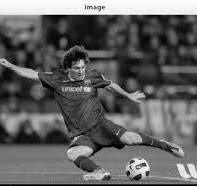

In [12]:
# Read an image from the path using OpenCV
from google.colab.patches import cv2_imshow

path = r"/content/messi5.jpg"
img = cv.imread(path)
# Show the image
cv2_imshow(img)

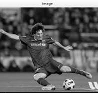

In [14]:
# Resizing the image to its half the width and half the height using resize()
res = cv.resize(img, None, fx=0.5, fy=0.5, interpolation = cv.INTER_CUBIC)
# Show the image
cv2_imshow(res)

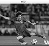

In [16]:
from google.colab.patches import cv2_imshow

# Resizing the image to its half the width and half the height using resize()
h, w = img.shape[:2]
img = cv.resize(img,(w//2, h//2), interpolation = cv.INTER_CUBIC)
# Show the image
cv2_imshow(img)

[[  1.   0. 100.]
 [  0.   1.  50.]]


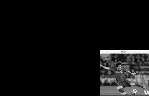

In [21]:
# Translate the image 100px right and 50px down
from google.colab.patches import cv2_imshow

rows,cols,width = img.shape
M = np.float32([[1,0,100],[0,1,50]])
print(M)
# To get full image add the translated value with row and col
dst = cv.warpAffine(img,M,(cols + 100,rows + 50))
# Show the image
cv2_imshow(dst)

[[ 6.123234e-17  1.000000e+00  1.500000e+00]
 [-1.000000e+00  6.123234e-17  4.650000e+01]]


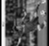

In [22]:
# Rotate the image to 90 degrees
from google.colab.patches import cv2_imshow

M = cv.getRotationMatrix2D(((cols-1)/2.0,(rows-1)/2.0),90,1)
print(M)
dst = cv.warpAffine(img,M,(cols,rows))
# Show the image
cv2_imshow(dst)

In [23]:
# Affine Transformation
path2 = r"/content/drawing.pnG" # Corrected path to an uploaded file
img2 = cv.imread(path2)
rows2,cols2,width2 = img2.shape
#Selecting two points
pts1 = np.float32([[20,50],[200,50],[50,200]])
pts2 = np.float32([[10,100],[200,50],[100,250]])
# Making the Affine Transformation Matrix
M = cv.getAffineTransform(pts1,pts2)
print(M)

[[  1.05555556   0.38888889 -30.55555556]
 [ -0.27777778   1.05555556  52.77777778]]


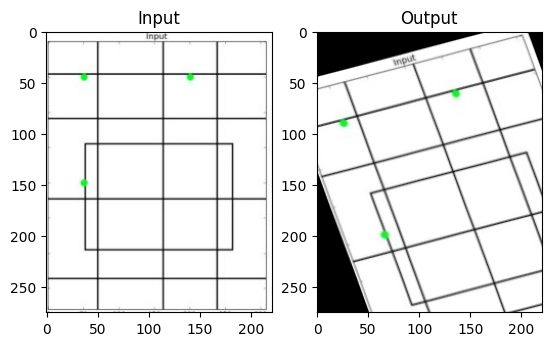

In [25]:
# Affine Transformed Image
dst = cv.warpAffine(img2,M,(cols2,rows2))
# Show as Subplots
plt.subplot(121),plt.imshow(img2),plt.title('Input')
plt.subplot(122),plt.imshow(dst),plt.title('Output')
plt.show()

In [36]:
path3 = r"/content/sudoku.png"
img3 = cv.imread(path3)
rows3,cols3,ch3 = img3.shape
pts1 = np.float32([[26,32],[183,27],[12,190],[193,190]])
pts2 = np.float32([[0,0],[200,0],[0,200],[200,200]])
M = cv.getPerspectiveTransform(pts1,pts2)
print(M)

[[ 1.36885430e+00  1.21290887e-01 -3.94715202e+01]
 [ 4.83137608e-02  1.51705209e+00 -4.98018247e+01]
 [ 2.41568804e-04  1.01152822e-03  1.00000000e+00]]


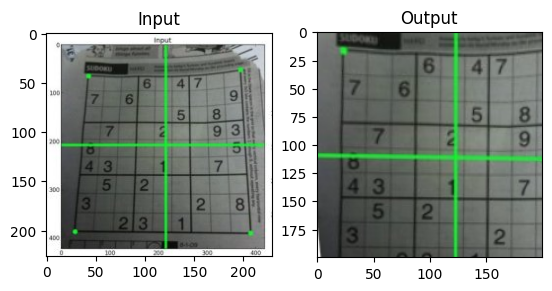

In [34]:
dst = cv.warpPerspective(img3,M,(200,200))
plt.subplot(121),plt.imshow(img3),plt.title('Input')
plt.subplot(122),plt.imshow(dst),plt.title('Output')
plt.show()


In [38]:
cv.imwrite(r"/content/sudoku_warped.jpg",dst)

True

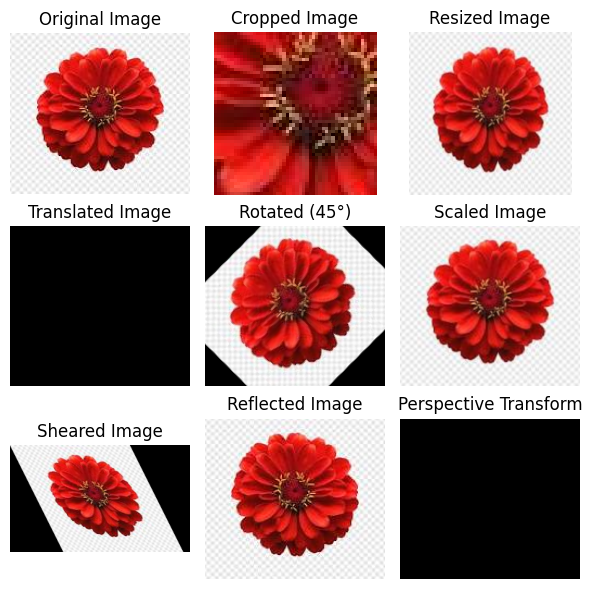

In [37]:
# Read image and convert from BGR to RGB for Matplotlib
path4 = r"/content/flower.jpg"
img4 = cv.imread(path4)
img_rgb = cv.cvtColor(img4, cv.COLOR_BGR2RGB)
# Get image dimensions
rows4, cols4 = img4.shape[:2]
# Create a 3x3 figure layout
plt.figure("Image Transformations", figsize=(6, 6))
# -------------------------------------------------
# 1. Original Image
# -------------------------------------------------
plt.subplot(3, 3, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
# -------------------------------------------------
# 2. Cropped Image
# -------------------------------------------------
# Crop a central region of the image
cropped = img4[50:100, 50:100] # Adjusted cropping coordinates
cropped_rgb = cv.cvtColor(cropped, cv.COLOR_BGR2RGB)
plt.subplot(3, 3, 2)
plt.imshow(cropped_rgb)
plt.title("Cropped Image")
plt.axis("off")
# -------------------------------------------------
# 3. Resized Image
# -------------------------------------------------
# Resize image to fixed dimensions
resized = cv.resize(img4, (500, 500))
resized_rgb = cv.cvtColor(resized, cv.COLOR_BGR2RGB)
plt.subplot(3, 3, 3)
plt.imshow(resized_rgb)
plt.title("Resized Image")
plt.axis("off")
# -------------------------------------------------
# 4. Translated Image
# -------------------------------------------------
# Translate image by 500 pixels in x and y directions
M_trans = np.float32([[1, 0, 500],
[0, 1, 500]])
translated = cv.warpAffine(img4, M_trans, (cols4, rows4))
translated_rgb = cv.cvtColor(translated, cv.COLOR_BGR2RGB)
plt.subplot(3, 3, 4)
plt.imshow(translated_rgb)
plt.title("Translated Image")
plt.axis("off")
# -------------------------------------------------
# 5. Rotated Image
# -------------------------------------------------
# Rotate image by 45 degrees about its center
center = (cols4 // 2, rows4 // 2)
M_rot = cv.getRotationMatrix2D(center, 45, 1.0)
rotated = cv.warpAffine(img4, M_rot, (cols4, rows4))
rotated_rgb = cv.cvtColor(rotated, cv.COLOR_BGR2RGB)
plt.subplot(3, 3, 5)
plt.imshow(rotated_rgb)
plt.title("Rotated (45°)")
plt.axis("off")
# -------------------------------------------------
# 6. Scaled Image
# -------------------------------------------------
# Scale image by a factor of 1.5
scaled = cv.resize(img4, None, fx=1.5, fy=1.5)
scaled_rgb = cv.cvtColor(scaled, cv.COLOR_BGR2RGB)
plt.subplot(3, 3, 6)
plt.imshow(scaled_rgb)
plt.title("Scaled Image")
plt.axis("off")
# -------------------------------------------------
# 7. Sheared Image
# -------------------------------------------------
# Apply horizontal shear transformation
M_shear = np.float32([[1, 0.5, 0],
[0, 1, 0]])
sheared = cv.warpAffine(img4, M_shear, (int(cols4 * 1.5), rows4))
sheared_rgb = cv.cvtColor(sheared, cv.COLOR_BGR2RGB)
plt.subplot(3, 3, 7)
plt.imshow(sheared_rgb)
plt.title("Sheared Image")
plt.axis("off")
# -------------------------------------------------
# 8. Reflected Image
# -------------------------------------------------
# Flip image horizontally
flipped = cv.flip(img4, 1)
flipped_rgb = cv.cvtColor(flipped, cv.COLOR_BGR2RGB)
plt.subplot(3, 3, 8)
plt.imshow(flipped_rgb)
plt.title("Reflected Image")
plt.axis("off")
# -------------------------------------------------
# 9. Perspective Transformation
# -------------------------------------------------
# Define source and destination points
pts1 = np.float32([
[250, 350],
[1450, 320],
[300, 1250],
[1400, 1200]
])
pts2 = np.float32([
[0, 0],
[1700, 0],
[0, 1500],
[1700, 1500]
])
# Compute perspective transformation matrix
M_persp = cv.getPerspectiveTransform(pts1, pts2)
perspective = cv.warpPerspective(img4, M_persp, (cols4, rows4))
perspective_rgb = cv.cvtColor(perspective, cv.COLOR_BGR2RGB)
plt.subplot(3, 3, 9)
plt.imshow(perspective_rgb)
plt.title("Perspective Transform")
plt.axis("off")
# -------------------------------------------------
# Adjust layout and display all plots
# -------------------------------------------------
plt.tight_layout()
plt.show()